# Laboratory Exercise: Core Deep Learning Concepts

Name: AGUARIN, Trish Ann Danielle || ANDAYA, Kurt Christian

---

## Learning Objectives

By the end of this activity you should be able to:

1. Compute forward and backward passes manually through a small computational graph.
2. Verify hand-computed gradients against PyTorch autograd.
3. Observe how weight initialization affects gradient magnitudes across network depth.
4. Implement dropout from scratch and measure its effect on generalization.
5. Compare the gradient behavior of sigmoid, tanh, and ReLU activations.
6. Diagnose and correct common learning rate problems through loss curve analysis.

---


In [2]:
# Environment check -- run this cell first
import importlib, sys
for pkg in ["torch", "numpy", "matplotlib"]:
    try:
        importlib.import_module(pkg)
        print(f"  ok  {pkg}")
    except ImportError:
        print(f"  MISSING  {pkg}  -- install with: pip install {pkg}")

import torch, numpy as np, matplotlib.pyplot as plt
torch.manual_seed(42)
np.random.seed(42)
print("\nPyTorch:", torch.__version__)

  ok  torch
  ok  numpy
  ok  matplotlib

PyTorch: 2.12.0+cpu


---
# Part 1 -- Backpropagation by Hand  (25 pts)

## Background

Backpropagation applies the **chain rule** repeatedly through a computational graph
to compute the gradient of the loss with respect to every parameter.

You will implement the complete backward pass yourself -- without using autograd --
then verify your result against PyTorch.

### Network architecture

```
Input x (2,)  -->  Hidden layer h (2,)  -->  Output y_hat (1,)  -->  Loss L
```

**Parameters:**  W1 (2x2), b1 (2,), W2 (1x2), b2 (1,)

**Forward pass equations (sigmoid activation):**

```
z1     = W1 @ x + b1
h      = sigmoid(z1)
z2     = W2 @ h + b2
y_hat  = z2                    (linear output)
L      = 0.5 * (y_hat - y)^2  (MSE loss)
```

**Useful derivatives:**

```
d/dz  sigmoid(z)        = sigmoid(z) * (1 - sigmoid(z))
d/df  0.5 * (f - y)^2   = f - y
```

## 1.1 Forward Pass

Run the cell below to set up the network and compute the forward pass.
All subsequent tasks use these same weights and inputs -- do not change them.

In [3]:
import numpy as np

# Fixed inputs and target -- do not change
x = np.array([0.5, -0.3])
y = np.array([1.0])

# Fixed initial weights -- do not change
W1 = np.array([[0.4, -0.2],
               [0.1,  0.8]])
b1 = np.array([0.0, 0.0])
W2 = np.array([[0.6, -0.5]])
b2 = np.array([0.0])

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

# Forward pass
z1    = W1 @ x + b1
h     = sigmoid(z1)
z2    = W2 @ h + b2
y_hat = z2
L     = 0.5 * (y_hat - y) ** 2

print("z1    =", z1)
print("h     =", h)
print("z2    =", z2)
print("y_hat =", y_hat)
print("L     =", float(L[0]))

z1    = [ 0.26 -0.19]
h     = [0.56463629 0.45264238]
z2    = [0.11246058]
y_hat = [0.11246058]
L     = 0.3938631073406956


## Task 1.1: Forward Pass  (5 pts)

Run the cell above and record the intermediate values.

**Questions:**

- What is the value of the hidden activation vector h?
- What is the scalar loss L?
- Is the network output closer to or further from the target (1.0) after the forward pass? By how much?

*Your answer:*

The value of h is [0.56463629 0.45264238], while the scalar loss is 0.3938631073406956. 

The network output is further from the target after the forward pass by 0.8875. 

## 1.2 Implementing the Backward Pass

Using the values computed in 1.1, implement the backward pass by filling in every
`# TODO` below. Use only NumPy -- do not call any autograd function.

Work through the chain rule from right to left:

```
L  -->  y_hat  -->  z2  -->  W2, b2, h  -->  z1  -->  W1, b1
```

The gradient at each node is: (upstream gradient) x (local derivative at that node).

In [4]:
# ---------------------------------------------------------------
# Task 1.2 -- fill in every TODO
# All values from the forward pass (z1, h, z2, y_hat, L, W1,
# b1, W2, b2, x, y) are already defined above. Run that cell first.
# ---------------------------------------------------------------

# Step 1: dL/dy_hat
dL_dyhat = y_hat - y 

# Step 2: dL/dz2  (y_hat = z2, linear node)
dL_dz2 = dL_dyhat

# Step 3: dL/dW2  (z2 = W2 @ h + b2) # shape: (1, 2)
dL_dW2 = dL_dz2 @ h.reshape(1, -1)

# Step 4: dL/db2
dL_db2 = dL_dz2

# Step 5: dL/dh
dL_dh = W2.T @ dL_dz2

# Step 6: sigmoid derivative at z1
sig_prime_z1 = h * (1 - h)

# Step 7: dL/dz1  (chain rule through sigmoid)
dL_dz1 = dL_dh * sig_prime_z1

# Step 8: dL/dW1  (outer product of dL_dz1 and x)
dL_dW1 = np.outer(dL_dz1, x) 

# Step 9: dL/db1
dL_db1 = dL_dz1

# -- do not delete these lines --
print("dL/dW1 =\n", dL_dW1)
print("dL/db1 =", dL_db1)
print("dL/dW2 =", dL_dW2)
print("dL/db2 =", dL_db2)

dL/dW1 =
 [[-0.06545305  0.03927183]
 [ 0.05497358 -0.03298415]]
dL/db1 = [-0.13090611  0.10994717]
dL/dW2 = [-0.50113696 -0.40173796]
dL/db2 = [-0.88753942]


## Task 1.2: Backward Pass  (10 pts)

Fill in every `# TODO` in the cell above.

**Questions:**

- (a) Before writing any code, write out the chain rule derivation for `dL/dW1`
step by step in the Markdown cell below. Use the notation from the Background section. Show every intermediate term.
- (b) What is the maximum possible value of sigmoid'(z)? What does this imply when the same function is applied across many layers?

*Your answer:*

a) dL / dW1 = dL/dy_hat * dy_hat/dz2 * dz2/dh * dh/dz1 * dz1/dW1

dL/dy_hat = y_hat - y \
dy_hat/dz2 = 1 \
dz2/dh = W2 \
dh/dz1 = h(1-h) \
dz1/dW1 = x 


b) The maximum value sigmoid'(z) is 0.25. This is when sigmoid(z) = 0.5.  This implies that since gradients are repeatedly multiplied by values <= 0.25 through many layers, they might shrink during backpropagation which causes vanushing gradient problem.




## 1.3 Verification with PyTorch Autograd

Run the cell below. It replicates the same forward pass in PyTorch and calls `.backward()`
automatically. If any maximum absolute difference exceeds `1e-6`, there is a bug in your
backward pass -- go back and fix it before moving on.

In [5]:
import torch, numpy as np

x_t  = torch.tensor([0.5, -0.3], dtype=torch.float64)
y_t  = torch.tensor([1.0],       dtype=torch.float64)

W1_t = torch.tensor([[0.4, -0.2], [0.1, 0.8]], dtype=torch.float64, requires_grad=True)
b1_t = torch.zeros(2, dtype=torch.float64, requires_grad=True)
W2_t = torch.tensor([[0.6, -0.5]], dtype=torch.float64, requires_grad=True)
b2_t = torch.zeros(1, dtype=torch.float64, requires_grad=True)

z1_t    = W1_t @ x_t + b1_t
h_t     = torch.sigmoid(z1_t)
z2_t    = W2_t @ h_t + b2_t
L_t     = 0.5 * (z2_t - y_t) ** 2
L_t.backward()

print("Gradients (autograd):")
print("  dL/dW1 =\n", W1_t.grad.numpy())
print("  dL/db1 =",    b1_t.grad.numpy())
print("  dL/dW2 =",    W2_t.grad.numpy())
print("  dL/db2 =",    b2_t.grad.numpy())

print("\nMax absolute difference vs. your manual gradients:")
print("  W1:", np.max(np.abs(W1_t.grad.numpy() - dL_dW1)))
print("  b1:", np.max(np.abs(b1_t.grad.numpy() - dL_db1)))
print("  W2:", np.max(np.abs(W2_t.grad.numpy() - dL_dW2)))
print("  b2:", np.max(np.abs(b2_t.grad.numpy() - dL_db2)))

Gradients (autograd):
  dL/dW1 =
 [[-0.06545305  0.03927183]
 [ 0.05497358 -0.03298415]]
  dL/db1 = [-0.13090611  0.10994717]
  dL/dW2 = [[-0.50113696 -0.40173796]]
  dL/db2 = [-0.88753942]

Max absolute difference vs. your manual gradients:
  W1: 1.3877787807814457e-17
  b1: 2.7755575615628914e-17
  W2: 0.0
  b2: 0.0


## Task 1.3: Autograd Verification  (5 pts)

In [6]:
# Task 1.3 (a)

# Task 1.3 (b) -- copy your 1.2 backward pass here, change sigmoid to tanh,
# and add a matching autograd check below

x = np.array([0.5, -0.3])
y = np.array([1.0])

W1 = np.array([[0.4, -0.2],
               [0.1,  0.8]])
b1 = np.zeros(2)
W2 = np.array([[0.6, -0.5]])
b2 = np.zeros(1)

z1 = W1 @ x + b1
h = np.tanh(z1)
z2 = W2 @ h + b2
y_hat = z2
L = 0.5 * (y_hat - y) ** 2

# Step 1: dL/dy_hat
dL_dyhat = y_hat - y 

# Step 2: dL/dz2  (linear output)
dL_dz2 = dL_dyhat

# Step 3: dL/dW2
dL_dW2 = dL_dz2 @ h.reshape(1, -1)

# Step 4: dL/db2
dL_db2 = dL_dz2

# Step 5: dL/dh
dL_dh = W2.T @ dL_dz2

# Step 6: tanh derivative at z1
tanh_prime_z1 = 1 - h**2

# Step 7: dL/dz1  (chain rule through tanh)
dL_dz1 = dL_dh * tanh_prime_z1

# Step 8: dL/dW1
dL_dW1 = np.outer(dL_dz1, x)

# Step 9: dL/db1
dL_db1 = dL_dz1

print("Gradients (manual):")
print("dL/dW1 =\n", dL_dW1)
print("dL/db1 =", dL_db1)
print("dL/dW2 =", dL_dW2)
print("dL/db2 =", dL_db2)


# same inputs
x_t  = torch.tensor([0.5, -0.3], dtype=torch.float64)
y_t  = torch.tensor([1.0], dtype=torch.float64)

W1_t = torch.tensor([[0.4, -0.2], [0.1, 0.8]], dtype=torch.float64, requires_grad=True)
b1_t = torch.zeros(2, dtype=torch.float64, requires_grad=True)
W2_t = torch.tensor([[0.6, -0.5]], dtype=torch.float64, requires_grad=True)
b2_t = torch.zeros(1, dtype=torch.float64, requires_grad=True)

# forward pass
z1_t = W1_t @ x_t + b1_t
h_t  = torch.tanh(z1_t)          # <-- changed from sigmoid
z2_t = W2_t @ h_t + b2_t
L_t  = 0.5 * (z2_t - y_t) ** 2

# backward
L_t.backward()

print("\n Gradients (autograd):")
print("  dL/dW1 =\n", W1_t.grad.numpy())
print("  dL/db1 =",    b1_t.grad.numpy())
print("  dL/dW2 =",    W2_t.grad.numpy())
print("  dL/db2 =",    b2_t.grad.numpy())

print("\nMax absolute difference vs. your manual gradients:")
print("  W1:", np.max(np.abs(W1_t.grad.numpy() - dL_dW1)))
print("  b1:", np.max(np.abs(b1_t.grad.numpy() - dL_db1)))
print("  W2:", np.max(np.abs(W2_t.grad.numpy() - dL_dW2)))
print("  b2:", np.max(np.abs(b2_t.grad.numpy() - dL_db2)))

Gradients (manual):
dL/dW1 =
 [[-0.21144611  0.12686767]
 [ 0.181747   -0.1090482 ]]
dL/db1 = [-0.42289223  0.36349399]
dL/dW2 = [-0.19162429  0.14147607]
dL/db2 = [-0.75354958]

 Gradients (autograd):
  dL/dW1 =
 [[-0.21144611  0.12686767]
 [ 0.181747   -0.1090482 ]]
  dL/db1 = [-0.42289223  0.36349399]
  dL/dW2 = [[-0.19162429  0.14147607]]
  dL/db2 = [-0.75354958]

Max absolute difference vs. your manual gradients:
  W1: 0.0
  b1: 0.0
  W2: 2.7755575615628914e-17
  b2: 0.0


**Questions:**

- (a) Report the max absolute difference per parameter. Do all values agree to numerical precision?
- (b) Modify your manual backward pass in 1.2 to use **tanh** instead of sigmoid
and re-run both the backward and verification cells. Update the derivative formula accordingly.
Do the gradients still match autograd?

*Your answer:*

a) The maximum absolute difference are around 1e-17. It agrees with the numerical precision.

b) Yes, the gradients match the autograd.

## 1.4 Training Loop

Using your backward pass from 1.2, implement a full gradient descent training loop.
After each forward-backward pass, update every parameter:

```
param = param - lr * gradient
```

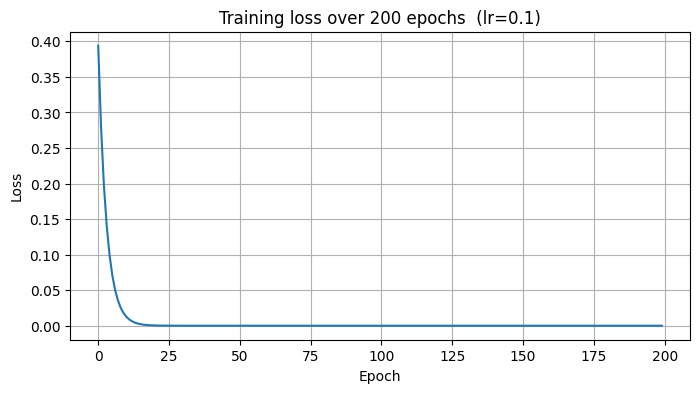

Initial loss : 0.393863
Final loss   : 0.000000


In [7]:
import numpy as np, matplotlib.pyplot as plt

# Re-initialize to starting values
W1_c = np.array([[0.4, -0.2], [0.1,  0.8]])
b1_c = np.array([0.0, 0.0])
W2_c = np.array([[0.6, -0.5]])
b2_c = np.array([0.0])

lr     = 0.1
epochs = 200
losses = []

for epoch in range(epochs):
    # -- Forward pass --
    z1_c    = W1_c @ x + b1_c
    h_c     = sigmoid(z1_c)
    z2_c    = W2_c @ h_c + b2_c
    y_hat_c = z2_c
    L_c     = 0.5 * (y_hat_c - y) ** 2
    losses.append(float(L_c[0]))

    # -- Backward pass: fill in every TODO --
    dL_dyhat_c = y_hat_c - y  
    dL_dz2_c   = dL_dyhat_c
    dL_dW2_c   = dL_dz2_c @ h_c.reshape(1, -1)
    dL_db2_c   = dL_dz2_c
    dL_dh_c    = W2_c.T @ dL_dz2_c
    sig_p_c    = h_c * (1 - h_c)
    dL_dz1_c   = dL_dh_c * sig_p_c
    dL_dW1_c   = np.outer(dL_dz1_c, x)
    dL_db1_c   = dL_dz1_c

    # -- Parameter update: fill in every TODO --
    W1_c = W1_c - lr * dL_dW1_c
    b1_c = b1_c - lr * dL_db1_c
    W2_c = W2_c - lr * dL_dW2_c
    b2_c = b2_c - lr * dL_db2_c

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss over 200 epochs  (lr=0.1)")
plt.grid(True)
plt.show()
print(f"Initial loss : {losses[0]:.6f}")
print(f"Final loss   : {losses[-1]:.6f}")

## Task 1.4: Gradient Descent Training Loop  (5 pts)

Fill in every `# TODO` in the training loop above.

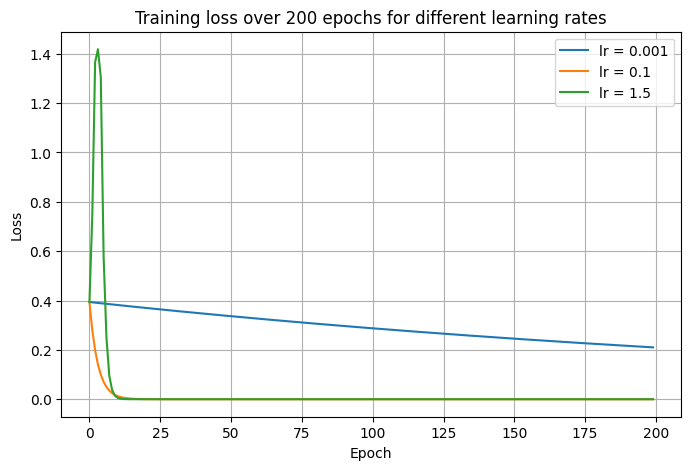

In [8]:
# Task 1.4 (b) -- compare lr = 0.001, 0.1, and 1.5 on one plot

def train(lr, x, y, epochs=200):

    W1_c = np.array([[0.4, -0.2], [0.1,  0.8]])
    b1_c = np.array([0.0, 0.0])
    W2_c = np.array([[0.6, -0.5]])
    b2_c = np.array([0.0])

    losses = []

    for epoch in range(epochs):
        # -- Forward pass --
        z1_c    = W1_c @ x + b1_c
        h_c     = sigmoid(z1_c)
        z2_c    = W2_c @ h_c + b2_c
        y_hat_c = z2_c
        L_c     = 0.5 * (y_hat_c - y) ** 2
        losses.append(float(L_c[0]))

        # -- Backward pass: 
        dL_dyhat_c = y_hat_c - y  
        dL_dz2_c   = dL_dyhat_c
        dL_dW2_c   = dL_dz2_c @ h_c.reshape(1, -1)
        dL_db2_c   = dL_dz2_c
        dL_dh_c    = W2_c.T @ dL_dz2_c
        sig_p_c    = h_c * (1 - h_c)
        dL_dz1_c   = dL_dh_c * sig_p_c
        dL_dW1_c   = np.outer(dL_dz1_c, x)
        dL_db1_c   = dL_dz1_c

        W1_c = W1_c - lr * dL_dW1_c
        b1_c = b1_c - lr * dL_db1_c
        W2_c = W2_c - lr * dL_dW2_c
        b2_c = b2_c - lr * dL_db2_c

    return losses

losses_0001 = train(0.001, x, y)
losses_01   = train(0.1, x, y)
losses_15   = train(1.5, x, y)

plt.figure(figsize=(8,5))

plt.plot(losses_0001, label="lr = 0.001")
plt.plot(losses_01,   label="lr = 0.1")
plt.plot(losses_15,   label="lr = 1.5")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss over 200 epochs for different learning rates")
plt.legend()
plt.grid(True)
plt.show()

**Questions:**
- (a) Run for 200 epochs at `lr=0.1`. Print the final loss.
- (b) Try `lr = 0.001`, `0.1`, and `1.5`. Plot all three loss curves on one figure.
- (c) Describe what happens at `lr=1.5`. Describe the loss curve shape at lr=1.5. What does this behavior indicate about the learning rate?

*Your answer:*

c) The loss did not smoothly decrease as the epoch increased at some point in the beginning. Instead, there was an overshoot that happened indicating that the learning rate might be too high for a stable convergence.



---
# Part 2 -- Solving Vanishing and Exploding Gradients  (25 pts)

## Background

You are given two broken networks. Both fail to train properly:
one suffers from **vanishing gradients**, the other from **exploding gradients**. Your job is to diagnose which network has which problem, then fix each one.

## 2.1 Diagnosing the Broken Networks

Run the diagnostic cell below. Do not modify it -- your job is to interpret the output.

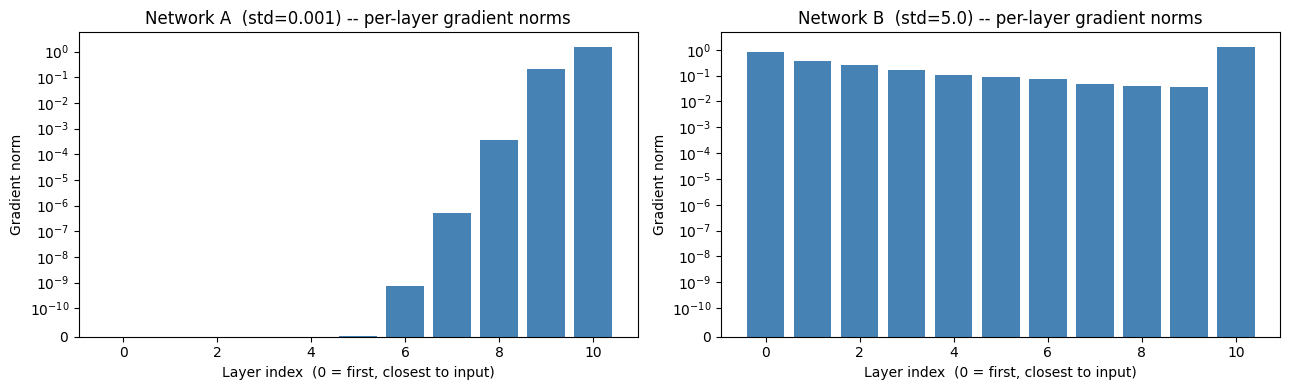

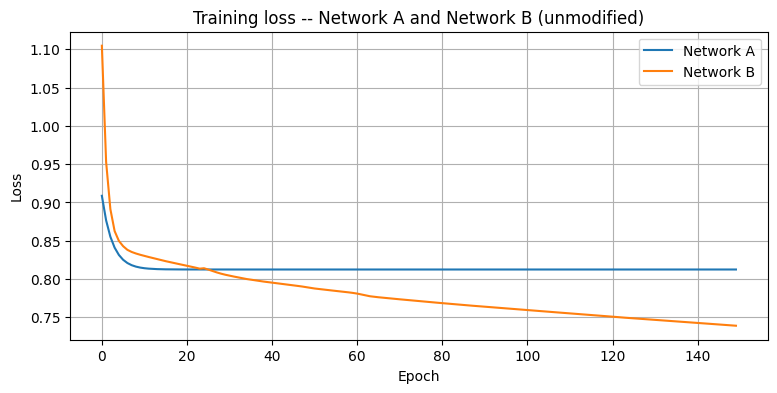

In [9]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

X_data = torch.randn(128, 32)
y_data = torch.randn(128, 1)

def build_net(depth, init_fn, activation=nn.Sigmoid):
    layers = []
    for _ in range(depth):
        lin = nn.Linear(32, 32, bias=True)
        init_fn(lin)
        layers += [lin, activation()]
    layers.append(nn.Linear(32, 1))
    return nn.Sequential(*layers)

def get_grad_norms(net):
    criterion = nn.MSELoss()
    out  = net(X_data)
    loss = criterion(out, y_data)
    loss.backward()
    norms = []
    for name, p in net.named_parameters():
        if "weight" in name and p.grad is not None:
            norms.append(p.grad.norm().item())
    return norms

def train_net(net, epochs=150, lr=0.01):
    opt       = torch.optim.SGD(net.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history   = []
    for _ in range(epochs):
        opt.zero_grad()
        loss = criterion(net(X_data), y_data)
        if torch.isnan(loss):
            history.append(float("nan"))
            break
        loss.backward()
        opt.step()
        history.append(loss.item())
    return history

# Network A: 10-layer sigmoid, very small weights
def init_A(layer):
    nn.init.normal_(layer.weight, std=0.001)
    nn.init.zeros_(layer.bias)

# Network B: 10-layer sigmoid, very large weights
def init_B(layer):
    nn.init.normal_(layer.weight, std=5.0)
    nn.init.zeros_(layer.bias)

net_A = build_net(10, init_A, nn.Sigmoid)
net_B = build_net(10, init_B, nn.Sigmoid)

norms_A = get_grad_norms(net_A)
norms_B = get_grad_norms(net_B)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, norms, label in [(axes[0], norms_A, "Network A  (std=0.001)"),
                          (axes[1], norms_B, "Network B  (std=5.0)")]:
    ax.bar(range(len(norms)), norms, color="steelblue")
    ax.set_title(f"{label} -- per-layer gradient norms")
    ax.set_xlabel("Layer index  (0 = first, closest to input)")
    ax.set_ylabel("Gradient norm")
    ax.set_yscale("symlog", linthresh=1e-10)
plt.tight_layout()
plt.show()

torch.manual_seed(0)
hist_A = train_net(build_net(10, init_A, nn.Sigmoid), lr=0.01)
hist_B = train_net(build_net(10, init_B, nn.Sigmoid), lr=0.01)

plt.figure(figsize=(9, 4))
plt.plot(hist_A, label="Network A")
plt.plot(hist_B, label="Network B")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss -- Network A and Network B (unmodified)")
plt.legend()
plt.grid(True)
plt.show()

## Task 2.1: Diagnose the Problems  (6 pts)

**Questions:**

**(a)** Based on the gradient norm bar charts, identify which network suffers from
vanishing gradients and which suffers from exploding gradients. Which network is vanishing? Which is exploding? State your evidence from the gradient norm plots.

**(b)** Explain mechanically why std=0.001 causes one problem and std=5.0 causes the other.

**(c)** Look at the pattern of gradient norms across layers.
In the vanishing case, are the early or late layers more affected?
In the exploding case, which layers are most dangerous?

*Your answer:*

**(a)** The network that suffers from vanishing gradients is Network A while Network B suffers from exploding gradients. This can be seen in the graph where the loss of Network A stalls, but the loss of Network B drops/diverges. We can also see in the gradient bar graph that the gradients near the input for network A are miniscule, while the gradients for network B are large.

**(b)** A std of 0.001 causes the weight initialization to start with values very close to 0 which makes the initial layers have small weights, while a std of 5 initializes the weights farther from 0 causing it to grow large overtime. 

**(c)** In both cases, the early layers are more affected/dangerous. For vanishing gradients, since the weights are small they would have small changes as well because it is the last reached through backpropagation. For exploding gradients, the same issue with backpropagation but since the gradients are large, they accumulate towards the earlier layers.

## 2.2 Fix the Vanishing Gradient Problem

Network A is failing to learn. Fix it by modifying the weight initialization
and/or activation function in the cell below.

**Your fix must satisfy both conditions:**
1. The gradient norm bar chart shows non-negligible gradients in all layers.
2. The training loss curve clearly decreases over 150 epochs.

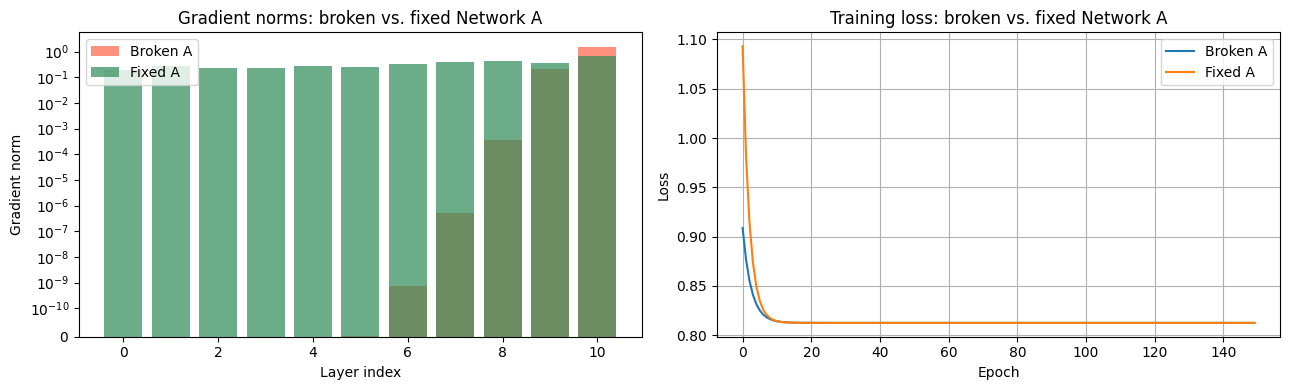

Broken A final loss: 0.8123341798782349
Fixed  A final loss: 0.8123336434364319


In [10]:
import torch, torch.nn as nn, matplotlib.pyplot as plt

torch.manual_seed(0)

def init_A_fixed(layer):
    # TODO: replace with a better initialization scheme
    nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
    nn.init.zeros_(layer.bias)

# TODO: change nn.Sigmoid to a different activation if needed
fixed_net_A = build_net(10, init_A_fixed, nn.ReLU)

# Gradient norm check
norms_fixed_A = get_grad_norms(fixed_net_A)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.bar(range(len(norms_A)),       norms_A,       color="tomato",   alpha=0.7, label="Broken A")
ax1.bar(range(len(norms_fixed_A)), norms_fixed_A, color="seagreen", alpha=0.7, label="Fixed A")
ax1.set_title("Gradient norms: broken vs. fixed Network A")
ax1.set_xlabel("Layer index")
ax1.set_ylabel("Gradient norm")
ax1.set_yscale("symlog", linthresh=1e-10)
ax1.legend()

torch.manual_seed(0)
hist_broken_A = train_net(build_net(10, init_A,       nn.Sigmoid), lr=0.01)
hist_fixed_A  = train_net(build_net(10, init_A_fixed, nn.Sigmoid), lr=0.01)

ax2.plot(hist_broken_A, label="Broken A")
ax2.plot(hist_fixed_A,  label="Fixed A")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.set_title("Training loss: broken vs. fixed Network A")
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

print("Broken A final loss:", hist_broken_A[-1])
print("Fixed  A final loss:", hist_fixed_A[-1])

## Task 2.2: Fix Vanishing Gradients  (10 pts)

Fill in `init_A_fixed` and update the activation if needed.


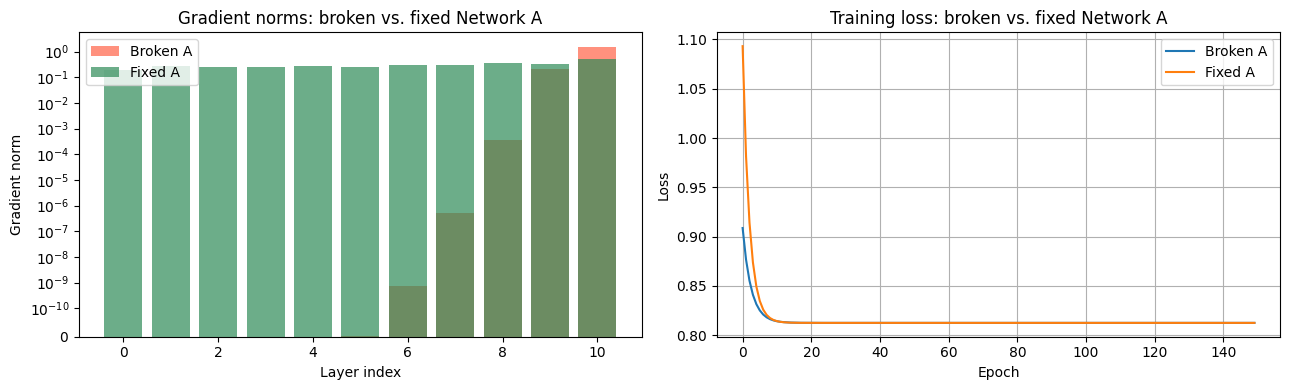

Broken A final loss: 0.8123341798782349
Fixed  A final loss: 0.8123335838317871


In [11]:
# Task 2.2 (c) -- experiment with a second combination here
import torch, torch.nn as nn, matplotlib.pyplot as plt

torch.manual_seed(0)

def init_A_fixed(layer):
    # TODO: replace with a better initialization scheme
    nn.init.kaiming_normal_(layer.weight, a=0.01, nonlinearity='leaky_relu')
    nn.init.zeros_(layer.bias)

# TODO: change nn.Sigmoid to a different activation if needed
fixed_net_A = build_net(10, init_A_fixed, nn.LeakyReLU)

# Gradient norm check
norms_fixed_A = get_grad_norms(fixed_net_A)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.bar(range(len(norms_A)),       norms_A,       color="tomato",   alpha=0.7, label="Broken A")
ax1.bar(range(len(norms_fixed_A)), norms_fixed_A, color="seagreen", alpha=0.7, label="Fixed A")
ax1.set_title("Gradient norms: broken vs. fixed Network A")
ax1.set_xlabel("Layer index")
ax1.set_ylabel("Gradient norm")
ax1.set_yscale("symlog", linthresh=1e-10)
ax1.legend()

torch.manual_seed(0)
hist_broken_A = train_net(build_net(10, init_A,       nn.Sigmoid), lr=0.01)
hist_fixed_A  = train_net(build_net(10, init_A_fixed, nn.Sigmoid), lr=0.01)

ax2.plot(hist_broken_A, label="Broken A")
ax2.plot(hist_fixed_A,  label="Fixed A")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.set_title("Training loss: broken vs. fixed Network A")
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

print("Broken A final loss:", hist_broken_A[-1])
print("Fixed  A final loss:", hist_fixed_A[-1])

**Questions:**

- (a) What changes did you make and why does this combination address vanishing gradients?
- (b) How did the gradient norms in the early layers change after your fix? Are the early layers
now receiving meaningful gradients?
- (c) Which combination produced the lowest final loss? Report the final training loss for each.

*Your answer:*

- (a) I changed the initialization to a He initialization fit for both relu and leaky relu, which I also did for the activation function. This addresses the vanishing gradients since sigmoid produces small gradients and the initialization works better optimized specifically for the activation function.
- (b) The early layers now produce meaningful gradients as seen with the graphs, this is large in part with the change in initialization and activation
- (c) Both relu and leaky relu produced a final loss of 0.8123336434364319 which is lower although not significantly than the loss of the broken network, 0.8123341798782349

## 2.3 Fix the Exploding Gradient Problem

Network B diverges or produces NaN. Fix it using one or more of these strategies:
- Better weight initialization (reduce the scale)
- Gradient clipping via `torch.nn.utils.clip_grad_norm_`
- Both

**Your fix must produce a stable, decreasing loss curve with no NaN values.**

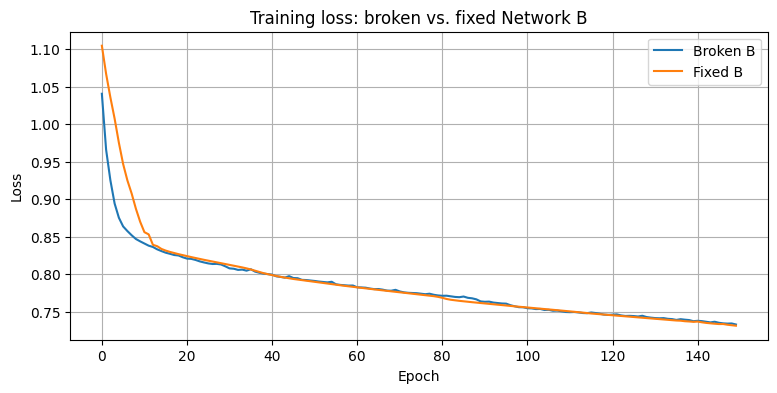

Broken B final loss: 0.7328766584396362
Fixed  B final loss: 0.7312452793121338


In [12]:
import torch, torch.nn as nn, matplotlib.pyplot as plt

torch.manual_seed(0)

def init_B_fixed(layer):
    # TODO: replace with a better initialization
    nn.init.normal_(layer.weight, std=5.0)
    nn.init.zeros_(layer.bias)

def train_net_fixed_B(net, epochs=150, lr=0.01, clip_value=None):
    opt       = torch.optim.SGD(net.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history   = []
    for _ in range(epochs):
        opt.zero_grad()
        loss = criterion(net(X_data), y_data)
        if torch.isnan(loss):
            history.append(float("nan"))
            break
        loss.backward()
        if clip_value is not None:
            # TODO: uncomment and complete this line if you use gradient clipping
            torch.nn.utils.clip_grad_norm_(net.parameters(), clip_value)
            pass
        opt.step()
        history.append(loss.item())
    return history

torch.manual_seed(0)
hist_broken_B = train_net(build_net(10, init_B,       nn.Sigmoid), lr=0.01)
hist_fixed_B  = train_net_fixed_B(build_net(10, init_B_fixed, nn.Sigmoid),
                                   lr=0.01, clip_value=1)

plt.figure(figsize=(9, 4))
plt.plot(hist_broken_B, label="Broken B")
plt.plot(hist_fixed_B,  label="Fixed B")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss: broken vs. fixed Network B")
plt.legend()
plt.grid(True)
plt.show()

print("Broken B final loss:", hist_broken_B[-1])
print("Fixed  B final loss:", hist_fixed_B[-1])

## Task 2.3: Fix Exploding Gradients  (9 pts)

Fill in `init_B_fixed` and enable gradient clipping if you use it.

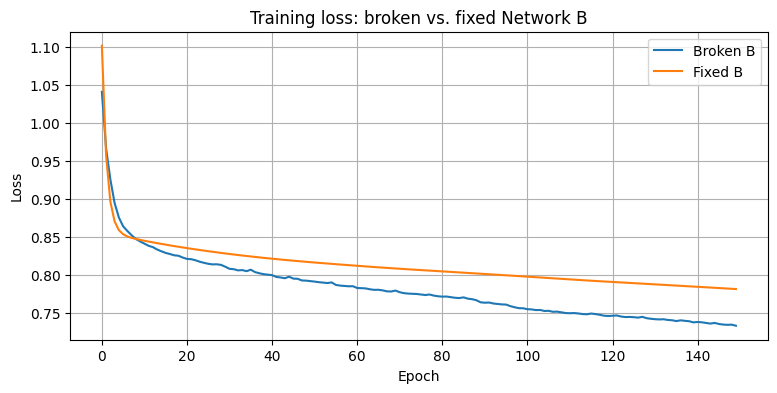

Broken B final loss: 0.7328766584396362
Fixed  B final loss: 0.7811086773872375


In [13]:
# Task 2.3  -- iniitialization fix alone
import torch, torch.nn as nn, matplotlib.pyplot as plt

torch.manual_seed(0)

def init_B_fixed(layer):
    # TODO: replace with a better initialization
    nn.init.normal_(layer.weight, std=2.5)
    nn.init.zeros_(layer.bias)

def train_net_fixed_B(net, epochs=150, lr=0.01, clip_value=None):
    opt       = torch.optim.SGD(net.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history   = []
    for _ in range(epochs):
        opt.zero_grad()
        loss = criterion(net(X_data), y_data)
        if torch.isnan(loss):
            history.append(float("nan"))
            break
        loss.backward()
        if clip_value is not None:
            # TODO: uncomment and complete this line if you use gradient clipping
            # torch.nn.utils.clip_grad_norm_(net.parameters(), clip_value)
            pass
        opt.step()
        history.append(loss.item())
    return history

torch.manual_seed(0)
hist_broken_B = train_net(build_net(10, init_B,       nn.Sigmoid), lr=0.01)
hist_fixed_B  = train_net_fixed_B(build_net(10, init_B_fixed, nn.Sigmoid),
                                   lr=0.01, clip_value=1)

plt.figure(figsize=(9, 4))
plt.plot(hist_broken_B, label="Broken B")
plt.plot(hist_fixed_B,  label="Fixed B")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss: broken vs. fixed Network B")
plt.legend()
plt.grid(True)
plt.show()

print("Broken B final loss:", hist_broken_B[-1])
print("Fixed  B final loss:", hist_fixed_B[-1])

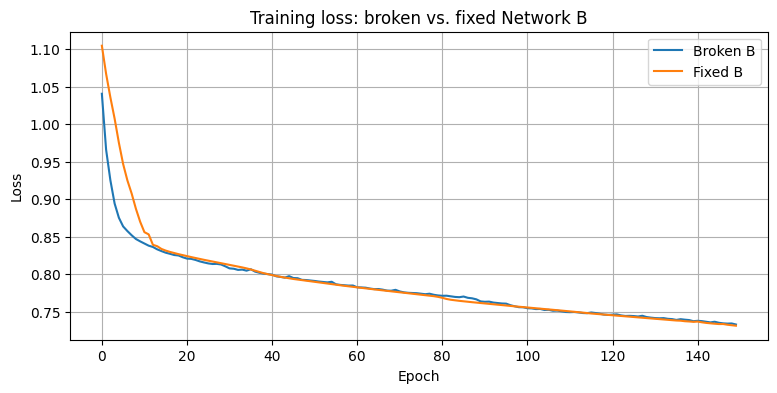

Broken B final loss: 0.7328766584396362
Fixed  B final loss: 0.7312452793121338


In [14]:
# Task 2.3  -- clipping alone: keep init_B (std=5.0), only add clipping
import torch, torch.nn as nn, matplotlib.pyplot as plt

torch.manual_seed(0)

def init_B_fixed(layer):
    # TODO: replace with a better initialization
    nn.init.normal_(layer.weight, std=5.0)
    nn.init.zeros_(layer.bias)

def train_net_fixed_B(net, epochs=150, lr=0.01, clip_value=None):
    opt       = torch.optim.SGD(net.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history   = []
    for _ in range(epochs):
        opt.zero_grad()
        loss = criterion(net(X_data), y_data)
        if torch.isnan(loss):
            history.append(float("nan"))
            break
        loss.backward()
        if clip_value is not None:
            # TODO: uncomment and complete this line if you use gradient clipping
            torch.nn.utils.clip_grad_norm_(net.parameters(), clip_value)
            pass
        opt.step()
        history.append(loss.item())
    return history

torch.manual_seed(0)
hist_broken_B = train_net(build_net(10, init_B,       nn.Sigmoid), lr=0.01)
hist_fixed_B  = train_net_fixed_B(build_net(10, init_B_fixed, nn.Sigmoid),
                                   lr=0.01, clip_value=1)

plt.figure(figsize=(9, 4))
plt.plot(hist_broken_B, label="Broken B")
plt.plot(hist_fixed_B,  label="Fixed B")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss: broken vs. fixed Network B")
plt.legend()
plt.grid(True)
plt.show()

print("Broken B final loss:", hist_broken_B[-1])
print("Fixed  B final loss:", hist_fixed_B[-1])

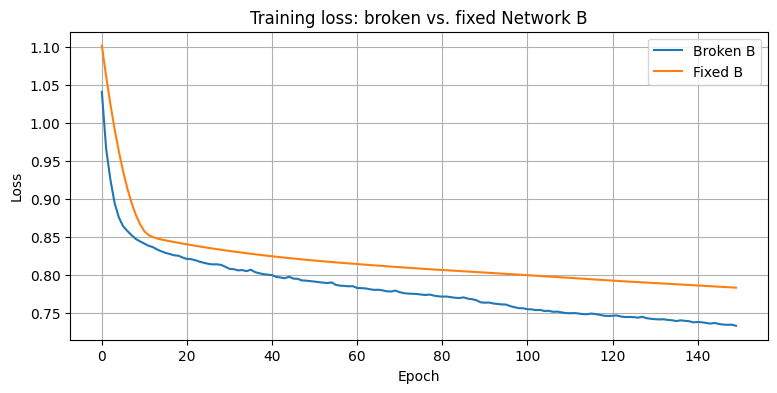

Broken B final loss: 0.7328766584396362
Fixed  B final loss: 0.7829225659370422


In [15]:
# Task 2.3 -- both combined: better init AND clipping
import torch, torch.nn as nn, matplotlib.pyplot as plt

torch.manual_seed(0)

def init_B_fixed(layer):
    # TODO: replace with a better initialization
    nn.init.normal_(layer.weight, std=2.5)
    nn.init.zeros_(layer.bias)

def train_net_fixed_B(net, epochs=150, lr=0.01, clip_value=None):
    opt       = torch.optim.SGD(net.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history   = []
    for _ in range(epochs):
        opt.zero_grad()
        loss = criterion(net(X_data), y_data)
        if torch.isnan(loss):
            history.append(float("nan"))
            break
        loss.backward()
        if clip_value is not None:
            # TODO: uncomment and complete this line if you use gradient clipping
            torch.nn.utils.clip_grad_norm_(net.parameters(), clip_value)
            pass
        opt.step()
        history.append(loss.item())
    return history

torch.manual_seed(0)
hist_broken_B = train_net(build_net(10, init_B,       nn.Sigmoid), lr=0.01)
hist_fixed_B  = train_net_fixed_B(build_net(10, init_B_fixed, nn.Sigmoid),
                                   lr=0.01, clip_value=1)

plt.figure(figsize=(9, 4))
plt.plot(hist_broken_B, label="Broken B")
plt.plot(hist_fixed_B,  label="Fixed B")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss: broken vs. fixed Network B")
plt.legend()
plt.grid(True)
plt.show()

print("Broken B final loss:", hist_broken_B[-1])
print("Fixed  B final loss:", hist_fixed_B[-1])

**Questions:**

- (a) Try three approaches in separate cells: initialization fix alone,
gradient clipping alone (keep std=5.0), and both combined.
Report the final loss and stability for each. Which approach worked best: init fix alone, clipping alone, or both? Report final loss values.
- (b) What initialization and/or clipping threshold did you use? Justify your choice.
- (c) How sensitive is the result to the clip threshold? What happens if it is set too low?

*Your answer:*

- (a) Among the 3 cases, the clipping alone performed the best having close loss to the broken albeit slightly less at 0.7318711280822754, the other two, init and both underperformed the broken with losses of 0.782922625541687 and 0.7811086773872375 respectively.
- (b) For the initialization, I tested different values before it started to vanish, and I came up with between 3 and 2. For the clipping threshold, I did some research and the general consensus is to have it at 1.
- (c) If set too low, the network will learn at a staggeringly snails pace since the weights wouldnt budge by more than that number, in which case itll have very small updates.

---
# Part 3 -- Dropout from Scratch  (20 pts)

## Background

**Dropout** is a regularization technique that randomly sets a fraction `p` of neuron
activations to zero during training. This prevents neurons from co-adapting too strongly
and acts as an ensemble of many sub-networks.

Key rules:
- During **training**: zero out each activation independently with probability `p`, then scale surviving activations by `1/(1-p)` (inverted dropout).
- During **inference**: use all activations unchanged (no zeroing, no scaling).

## 3.1 Implementing Dropout from Scratch

In [16]:
import torch

def dropout(X, p, training=True):
    """
    Apply inverted dropout to tensor X.
    p      : probability of zeroing a unit (drop rate)
    training: if False, return X unchanged
    """
    if not training or p == 0.0:
        return X
    assert 0 < p < 1, "p must be in (0, 1)"
    # Bernoulli mask: 1 with probability (1-p), 0 with probability p
    mask = (torch.rand_like(X) > p).float()
    return mask * X / (1.0 - p)

# Quick sanity checks
torch.manual_seed(0)
X_test = torch.ones(4, 6)

out_train = dropout(X_test, p=0.5, training=True)
out_eval  = dropout(X_test, p=0.5, training=False)

print("Input (all ones, shape 4x6):")
print(X_test)
print("\nDropout p=0.5, training=True:")
print(out_train)
print("\nDropout p=0.5, training=False:")
print(out_eval)
print("\nExpected mean (training, inverted):", out_train.mean().item())
print("Expected mean (eval)              :", out_eval.mean().item())

Input (all ones, shape 4x6):
tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])

Dropout p=0.5, training=True:
tensor([[0., 2., 0., 0., 0., 2.],
        [0., 2., 0., 2., 0., 0.],
        [0., 0., 0., 2., 2., 2.],
        [0., 0., 2., 2., 0., 2.]])

Dropout p=0.5, training=False:
tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])

Expected mean (training, inverted): 0.8333333134651184
Expected mean (eval)              : 1.0


## Task 3.1: Implement Dropout  (7 pts)

In [17]:
# Task 3.1 (c) -- verify expected mean for multiple drop rates
import torch

torch.manual_seed(42)
X_check = torch.ones(100, 100)

for p in [0.1, 0.3, 0.5, 0.7]:
    means = [dropout(X_check, p=p, training=True).mean().item() for _ in range(1000)]
    print(f"p={p:.1f}  |  mean over 1000 trials: {sum(means)/len(means):.4f}  (expected 1.0)")

p=0.1  |  mean over 1000 trials: 1.0000  (expected 1.0)
p=0.3  |  mean over 1000 trials: 1.0001  (expected 1.0)
p=0.5  |  mean over 1000 trials: 0.9996  (expected 1.0)
p=0.7  |  mean over 1000 trials: 1.0002  (expected 1.0)


**Questions:**

- (a) Run the cell. Why does `training=False` return the input unchanged?
- (b) Why do we scale the surviving activations by `1/(1-p)` during training? What problem does this solve at inference time?
- (c) In the cell below, verify that the **expected mean** of the dropout output equals the input mean for several values of `p` (try 0.1, 0.3, 0.5, 0.7). Run each case 1000 times and average.

*Your answer:*

a) Putting training = false means disabling the dropout. This means no units will be dropped and no scaling will be applied. The layer will simply pass the input unchanged. 

b) We scale the surviving activations so that the expected value of the output stays the same as the input. This solves the feature-scale mismatch problem at inference time by ensuring the network receives the same aggregate magnitude of inputs as it learned to expect during training

c) The results show that in any value of p, the mean stays approx equal 1.0. This confirms that the scaling factor compensates to the missing activations, keeping the overall expextation unchanged.

## 3.2 Dropout as a Regularizer -- Overfitting Demo

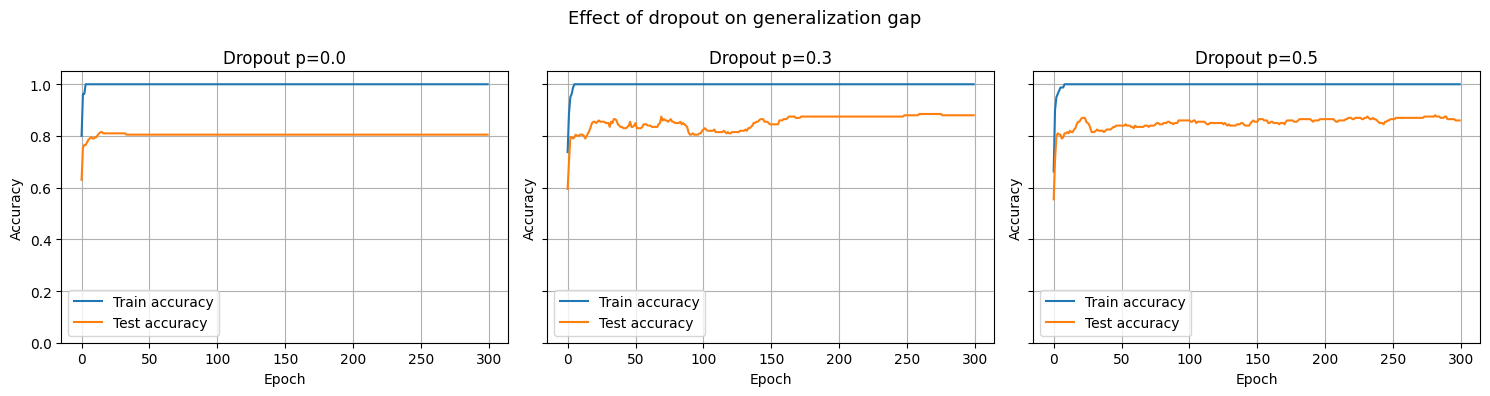

In [18]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

# Small dataset -- easy to overfit
N_train, N_test = 80, 200
X_train = torch.randn(N_train, 20)
y_train = (X_train[:, 0] > 0).long()   # label depends only on first feature
X_test  = torch.randn(N_test,  20)
y_test  = (X_test[:,  0] > 0).long()

class Net(nn.Module):
    def __init__(self, drop_p=0.0):
        super().__init__()
        self.fc1 = nn.Linear(20, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 2)
        self.drop_p = drop_p

    def forward(self, x, training=True):
        x = torch.relu(self.fc1(x))
        x = dropout(x, p=self.drop_p, training=training)
        x = torch.relu(self.fc2(x))
        x = dropout(x, p=self.drop_p, training=training)
        return self.fc3(x)

def run_experiment(drop_p, epochs=300, lr=0.01):
    torch.manual_seed(0)
    net = Net(drop_p=drop_p)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    train_acc, test_acc = [], []
    for _ in range(epochs):
        net.train()
        opt.zero_grad()
        loss = criterion(net(X_train, training=True), y_train)
        loss.backward()
        opt.step()
        with torch.no_grad():
            tr_acc = (net(X_train, training=False).argmax(1) == y_train).float().mean().item()
            te_acc = (net(X_test,  training=False).argmax(1) == y_test ).float().mean().item()
        train_acc.append(tr_acc)
        test_acc.append(te_acc)
    return train_acc, test_acc

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, p in zip(axes, [0.0, 0.3, 0.5]):
    tr, te = run_experiment(p)
    ax.plot(tr, label="Train accuracy")
    ax.plot(te, label="Test accuracy")
    ax.set_title(f"Dropout p={p}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(True)

plt.suptitle("Effect of dropout on generalization gap", fontsize=13)
plt.tight_layout()
plt.show()

## Task 3.2: Overfitting Demo  (8 pts)


**Questions:**

- (a)  Run the experiment. For each dropout rate, report the final train and test accuracy. Report final train and test accuracy for p=0.0, 0.3, and 0.5.
- (b) Which dropout rate gives the best **test** accuracy? Does a higher drop rate always help?
- (c) What happened at p=0.8? Explain the mechanism.
- (d) In the cell below, replace your custom dropout() with nn.Dropout(p) and verify you get equivalent results.

*Your answer:*

a) p = 0.0 
Train accuracy = 1.0
Test accuracy ≈ 0.8 

p = 0.3
Train accuracy = 1.0
Test accuracy ≈ 0.88

p = 0.5 
Train accuracy = 1.0
Test accuracy ≈ 0.86 

b) The dropout rate that gave the best test accuraacy is p = 0.3. Higher dropout doesn't always in achieving a higher test accuracy.

c) At p = 0.8, most neurons will be dropped during training which would leave little amount of active units the model could refer to learn the pattern. It might cause an underfitting which would drop the accuracy both in train and test.

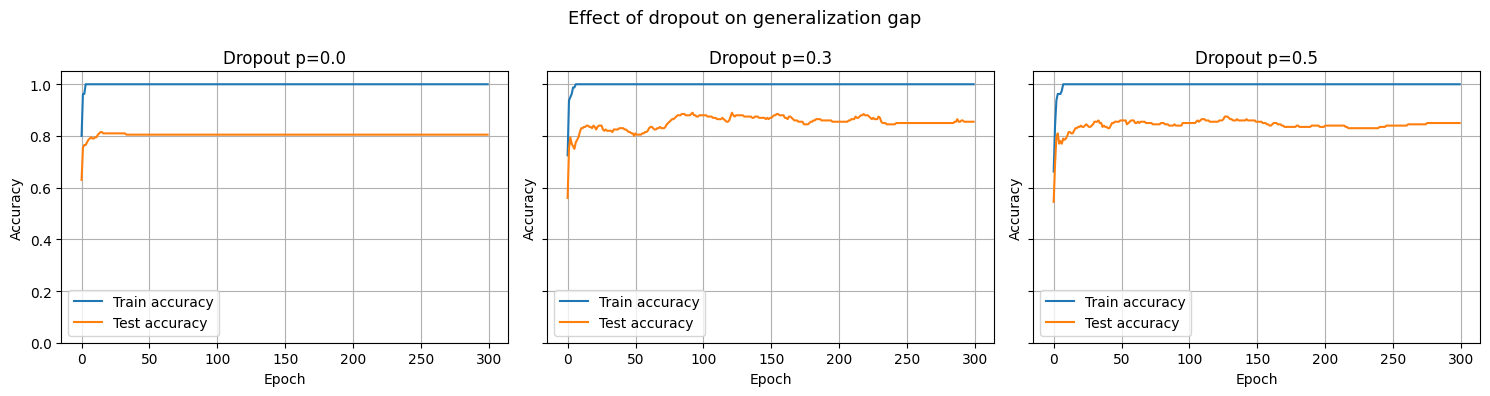

In [19]:
# Task 3.2 (d) -- replace custom dropout with nn.Dropout and compare
torch.manual_seed(42)

N_train, N_test = 80, 200
X_train = torch.randn(N_train, 20)
y_train = (X_train[:, 0] > 0).long()   
X_test  = torch.randn(N_test,  20)
y_test  = (X_test[:,  0] > 0).long()

class Net(nn.Module):
    def __init__(self, drop_p=0.0):
        super().__init__()
        self.fc1 = nn.Linear(20, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 2)
        self.drop_p = nn.Dropout(p=drop_p)

    def forward(self, x, training=True):
        x = torch.relu(self.fc1(x))
        if training:
            x = self.drop_p(x)
        x = torch.relu(self.fc2(x))
        if training:
            x = self.drop_p(x)
        return self.fc3(x)

def run_experiment(drop_p, epochs=300, lr=0.01):
    torch.manual_seed(0)
    net = Net(drop_p=drop_p)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    train_acc, test_acc = [], []
    for _ in range(epochs):
        net.train()
        opt.zero_grad()
        loss = criterion(net(X_train, training=True), y_train)
        loss.backward()
        opt.step()
        with torch.no_grad():
            tr_acc = (net(X_train, training=False).argmax(1) == y_train).float().mean().item()
            te_acc = (net(X_test, training=False).argmax(1) == y_test).float().mean().item()
        train_acc.append(tr_acc)
        test_acc.append(te_acc)
    return train_acc, test_acc


fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, p in zip(axes, [0.0, 0.3, 0.5]):
    tr, te = run_experiment(p)
    ax.plot(tr, label="Train accuracy")
    ax.plot(te, label="Test accuracy")
    ax.set_title(f"Dropout p={p}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(True)

plt.suptitle("Effect of dropout on generalization gap", fontsize=13)
plt.tight_layout()
plt.show()

## 3.3 train() vs. eval() Mode

## Task 3.3: train() vs eval() Mode  (5 pts)

This task has no starter code -- you will write it from scratch.

In [20]:
# Task 3.3 -- train() vs eval() mode demo
torch.manual_seed(42)

net = nn.Sequential(
    nn.Linear(10, 10),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(10, 2)
)
x = torch.randn(5, 10)

net.train()
with torch.no_grad():
    out_train_1 = net(x)
    out_train_2 = net(x)

print("Train mode output:")
print("Pass 1:\n", out_train_1)
print("Pass 2:\n", out_train_2)

net.eval()
with torch.no_grad():
    out_eval_1 = net(x)
    out_eval_2 = net(x)

print("\nEval mode output:")
print("Pass 1:\n", out_eval_1)
print("Pass 2:\n", out_eval_2)

Train mode output:
Pass 1:
 tensor([[ 0.0737, -0.2364],
        [ 0.3498,  0.0810],
        [ 0.2504, -0.1278],
        [ 0.2698,  0.0965],
        [-0.2614, -0.2442]])
Pass 2:
 tensor([[ 0.3269, -0.0094],
        [ 0.2721,  0.0985],
        [ 0.5411, -0.0850],
        [ 0.2936,  0.0937],
        [ 0.2261, -0.0178]])

Eval mode output:
Pass 1:
 tensor([[ 0.2208, -0.0688],
        [ 0.1899,  0.0141],
        [ 0.4988, -0.0140],
        [ 0.2114,  0.0545],
        [ 0.0489, -0.0826]])
Pass 2:
 tensor([[ 0.2208, -0.0688],
        [ 0.1899,  0.0141],
        [ 0.4988, -0.0140],
        [ 0.2114,  0.0545],
        [ 0.0489, -0.0826]])


**Questions:**

- (a)  Build a small network using `nn.Dropout(0.5)`. Print a batch of outputs in `net.train()` mode and `net.eval()` mode on the **same input**. Are they the same? Why or why not?
- (b) Explain why calling `net.eval()` before inference is critical in production.

*Your answer:*

a) The outputs are NOT the same since in train(), drouput randomly sets activations to 0, so outputs will change every forward pass. In eval(), dropout is completely off so all activations are used.

b) Calling net.eval() before inference is critical because it would directly impact the prediction accuracy as its outputs are 100% deterministic. Without it, dropout will be active, which might lead to unreliable predictions.

---
# Part 4 -- Activation Function Comparison  (20 pts)

## Background

The choice of activation function affects:
- The **range** of outputs from each neuron.
- The **magnitude of gradients** flowing back through the network.
- Susceptibility to the **vanishing gradient problem**.

## 4.1 Plotting Activations and Their Derivatives

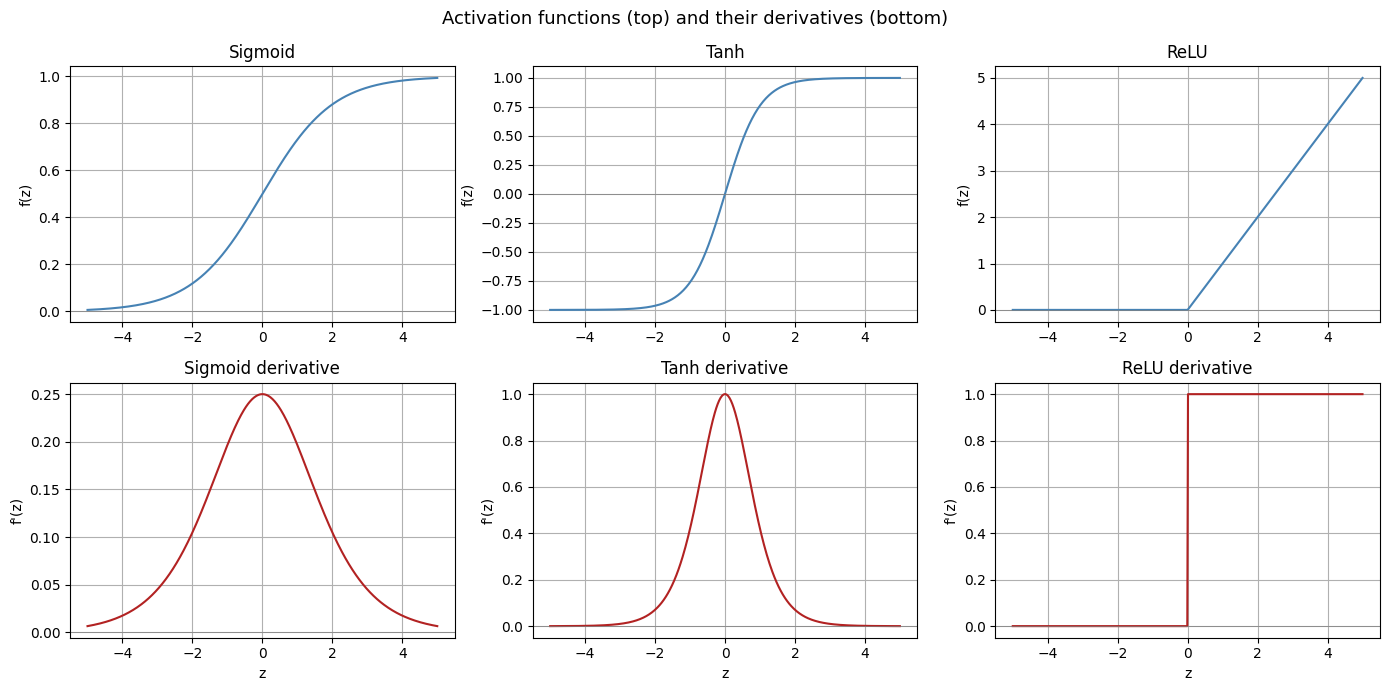

In [21]:
import torch
import matplotlib.pyplot as plt

z = torch.linspace(-5, 5, 500, requires_grad=False)

def compute(fn, z):
    z_ = z.clone().requires_grad_(True)
    out = fn(z_)
    out.sum().backward()
    return out.detach(), z_.grad.detach()

activations = {
    "Sigmoid": torch.sigmoid,
    "Tanh":    torch.tanh,
    "ReLU":    torch.relu,
}

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for col, (name, fn) in enumerate(activations.items()):
    vals, grads = compute(fn, z)
    axes[0, col].plot(z.numpy(), vals.numpy(), color="steelblue")
    axes[0, col].set_title(f"{name}")
    axes[0, col].set_ylabel("f(z)")
    axes[0, col].axhline(0, color="gray", lw=0.5)
    axes[0, col].grid(True)

    axes[1, col].plot(z.numpy(), grads.numpy(), color="firebrick")
    axes[1, col].set_title(f"{name} derivative")
    axes[1, col].set_ylabel("f'(z)")
    axes[1, col].set_xlabel("z")
    axes[1, col].axhline(0, color="gray", lw=0.5)
    axes[1, col].grid(True)

plt.suptitle("Activation functions (top) and their derivatives (bottom)", fontsize=13)
plt.tight_layout()
plt.show()

## Task 4.1: Plot and Analyze  (6 pts)

**Questions:**

- (a) State the maximum gradient for sigmoid, tanh, and ReLU. At what z value is each maximum achieved?
- (b) Which activations cause vanishing gradients in deep networks, and why?
- (c) What is the dead ReLU problem? What does the derivative plot reveal about it?

*Your answer:*

- (a) For sigmoid, tanh and ReLu, the maximum gradients are 0.25, 1 and 1 respectively. For the z value where it is achieved, its on 0, 0 again, and 0 onwards respectively.
- (b) Both sigmoid and tanh since both are saturated on the positive and negative side as seen in the graphs where both taper off to be 0 on the negative and positive side.
- (c) Since ReLu operates using max(0,x), if a neurons weights are updated as negative, it might die since it would not have improvements which can be seen in the derivative plot where the derivative of the function below 0 is just 0.

## 4.2 Gradient Magnitude Across Network Depth

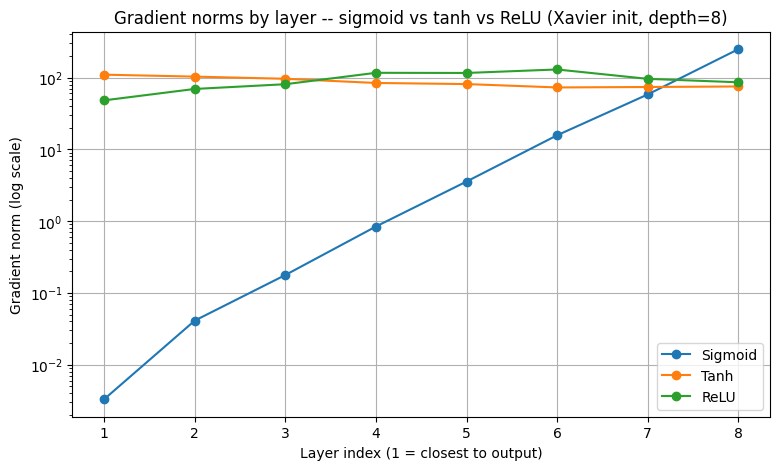

In [22]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

def gradient_norms_by_layer(activation_fn, depth=8, width=64, seed=42):
    torch.manual_seed(seed)
    layers = []
    for _ in range(depth):
        lin = nn.Linear(width, width)
        nn.init.xavier_uniform_(lin.weight)
        nn.init.zeros_(lin.bias)
        layers += [lin, activation_fn()]
    net = nn.Sequential(*layers)

    x = torch.randn(32, width)
    y = net(x).sum()
    y.backward()

    norms = []
    for layer in net:
        if isinstance(layer, nn.Linear) and layer.weight.grad is not None:
            norms.append(layer.weight.grad.norm().item())
    return norms

plt.figure(figsize=(9, 5))
for name, fn in [("Sigmoid", nn.Sigmoid), ("Tanh", nn.Tanh), ("ReLU", nn.ReLU)]:
    norms = gradient_norms_by_layer(fn)
    plt.plot(range(1, len(norms)+1), norms, marker="o", label=name)

plt.xlabel("Layer index (1 = closest to output)")
plt.ylabel("Gradient norm (log scale)")
plt.yscale("log")
plt.title("Gradient norms by layer -- sigmoid vs tanh vs ReLU (Xavier init, depth=8)")
plt.legend()
plt.grid(True)
plt.show()

## Task 4.2: Gradient Flow Analysis  (8 pts)

**Questions:**

- (a) Rank the three activations by how well they preserve gradient magnitude. Which wins and why?
- (b) Does the relative ranking change at depth=16? What does this suggest about scaling?
- (c) Tanh has a larger maximum derivative than sigmoid. How does this translate to better gradient flow?

*Your answer:*

- (a) Initially from the graphs, Tanh preserves the best, followed by ReLu and lastly by sigmoid. This is because Tanh and ReLu can both achieve 1 as a gradient since they both have maximum derivatives of 1.
- (b) On depth=16, it looks like ReLu maintains the gradient flow better, this can be explained by ReLu having a constant 1.0 for the derivative for any positive value while tanh requiring a value of 0 to achieve a derivative of 1.
- (c) Since gradients are multiplied through backpropagation, having a maximum of 1 helps in maintaining the gradient since if it is multiplied through many layers, the gradient stays relatively the same, which cannot be said for sigmoid with a maximum of 0.25, since in the best case, each layer essentially fourths the gradient.

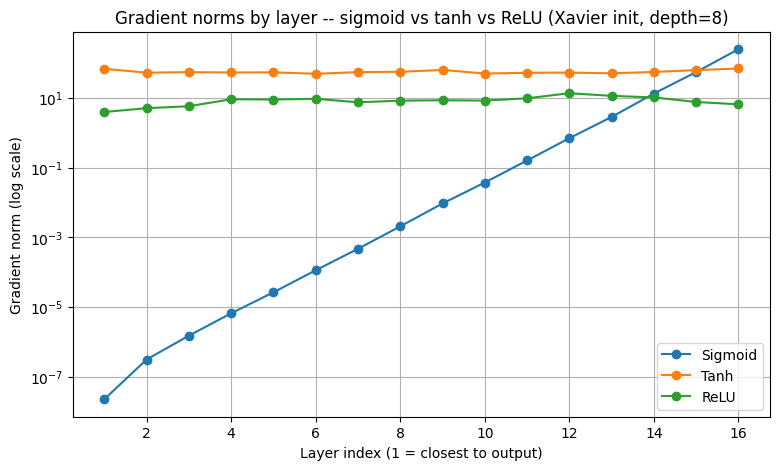

In [23]:
# Task 4.2 (b) -- repeat with depth=16
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

def gradient_norms_by_layer(activation_fn, depth=8, width=64, seed=42):
    torch.manual_seed(seed)
    layers = []
    for _ in range(depth):
        lin = nn.Linear(width, width)
        nn.init.xavier_uniform_(lin.weight)
        nn.init.zeros_(lin.bias)
        layers += [lin, activation_fn()]
    net = nn.Sequential(*layers)

    x = torch.randn(32, width)
    y = net(x).sum()
    y.backward()

    norms = []
    for layer in net:
        if isinstance(layer, nn.Linear) and layer.weight.grad is not None:
            norms.append(layer.weight.grad.norm().item())
    return norms

plt.figure(figsize=(9, 5))
for name, fn in [("Sigmoid", nn.Sigmoid), ("Tanh", nn.Tanh), ("ReLU", nn.ReLU)]:
    norms = gradient_norms_by_layer(fn, depth=16)
    plt.plot(range(1, len(norms)+1), norms, marker="o", label=name)

plt.xlabel("Layer index (1 = closest to output)")
plt.ylabel("Gradient norm (log scale)")
plt.yscale("log")
plt.title("Gradient norms by layer -- sigmoid vs tanh vs ReLU (Xavier init, depth=8)")
plt.legend()
plt.grid(True)
plt.show()

## 4.3 Training Speed Comparison

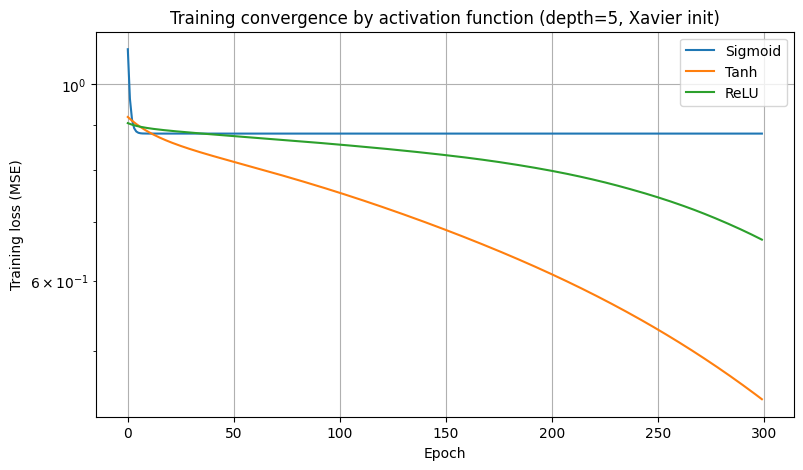

Sigmoid  Final Loss: 0.879929
Tanh     Final Loss: 0.441090
ReLU     Final Loss: 0.667893


In [24]:
import torch, torch.nn as nn, matplotlib.pyplot as plt

def train_with_activation(act_fn, depth=5, width=64, epochs=300, lr=0.01, seed=0):
    torch.manual_seed(seed)
    layers = []
    for _ in range(depth):
        lin = nn.Linear(width, width)
        nn.init.xavier_uniform_(lin.weight)
        layers += [lin, act_fn()]
    layers.append(nn.Linear(width, 1))
    net = nn.Sequential(*layers)

    X = torch.randn(256, width)
    y = torch.randn(256, 1)
    opt = torch.optim.SGD(net.parameters(), lr=lr)
    criterion = nn.MSELoss()

    history = []
    for _ in range(epochs):
        opt.zero_grad()
        loss = criterion(net(X), y)
        loss.backward()
        opt.step()
        history.append(loss.item())
    return history
final_losses = {}
plt.figure(figsize=(9, 5))
for name, fn in [("Sigmoid", nn.Sigmoid), ("Tanh", nn.Tanh), ("ReLU", nn.ReLU)]:
    h = train_with_activation(fn)
    plt.plot(h, label=name)
    final_losses[name] = h[-1]

plt.xlabel("Epoch")
plt.ylabel("Training loss (MSE)")
plt.yscale("log")
plt.title("Training convergence by activation function (depth=5, Xavier init)")
plt.legend()
plt.grid(True)
plt.show()

for name, loss in final_losses.items():
    print(f"{name:<8} Final Loss: {loss:.6f}")

## Task 4.3: Training Convergence  (6 pts)

**Questions:**

- (a) Run the experiment. Which activation converges fastest at depth=5? Summarize the final loss for each.
- (b) Re-run with `depth=10`. Does the winner change? Why?
- (c) Experiment with **Leaky ReLU** (`nn.LeakyReLU`) and add it to the plot. Does it outperform standard ReLU?

*Your answer:*

- (a) The clear winner from the graph itself is tanh, followed by ReLu then sigmoid with the loss as the following:
Sigmoid  Final Loss: 0.879929
Tanh     Final Loss: 0.441090
ReLU     Final Loss: 0.667934
- (b) Even at depth 10, the heirarchy stays the same, even worse, the loss of ReLu and LeakyReLu went to a standstill as the gradients vanished, although if we replace the initialization to He, the results of both ReLu will be better. Upon further experimentation though, it looks like tanh breaks down and reverses its loss on a deeper network, while the ReLu's maintain the same consistent downward trend albeit with some zigzagging. Tanh converges fast because it is a 0 centered algorithm where its values can be between -1 and 1.
- (c) The performance of LeakyReLu is almost the same with ReLu with the caveat that Leaky ReLu has less dramatic zigzagging compared to ReLu. In that sense, since the gradients dont jump as high as ReLu it can be said that LeakyReLu outperforms ReLu. Another thing that helps LeakyReLu is the fact that, like tanh, it is also considering negative values.

C:\Users\Trish Ann Aguarin\AppData\Local\Temp\ipykernel_13352\3632137842.py:10: FutureWarning: `nn.init.kaiming_uniform` is now deprecated in favor of `nn.init.kaiming_uniform_`.
  nn.init.kaiming_uniform(lin.weight)


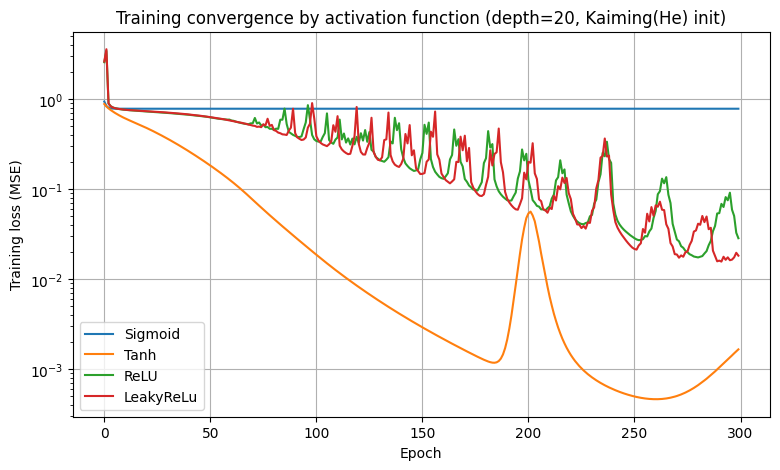

Sigmoid  Final Loss: 0.785288
Tanh     Final Loss: 0.001667
ReLU     Final Loss: 0.028620
LeakyReLu Final Loss: 0.018319


In [25]:
# Task 4.3 (b) and (c) -- depth=10 and add Leaky ReLU

import torch, torch.nn as nn, matplotlib.pyplot as plt

def train_with_activation(act_fn, depth=5, width=64, epochs=300, lr=0.01, seed=0):
    torch.manual_seed(seed)
    layers = []
    for _ in range(depth):
        lin = nn.Linear(width, width)
        nn.init.kaiming_uniform(lin.weight)
        layers += [lin, act_fn()]
    layers.append(nn.Linear(width, 1))
    net = nn.Sequential(*layers)

    X = torch.randn(256, width)
    y = torch.randn(256, 1)
    opt = torch.optim.SGD(net.parameters(), lr=lr)
    criterion = nn.MSELoss()

    history = []
    for _ in range(epochs):
        opt.zero_grad()
        loss = criterion(net(X), y)
        loss.backward()
        opt.step()
        history.append(loss.item())
    return history
final_losses = {}

plt.figure(figsize=(9, 5))
for name, fn in [("Sigmoid", nn.Sigmoid), ("Tanh", nn.Tanh), ("ReLU", nn.ReLU), 
                 ("LeakyReLu", nn.LeakyReLU)]:
    h = train_with_activation(fn, depth=20)
    plt.plot(h, label=name)
    final_losses[name] = h[-1]


plt.xlabel("Epoch")
plt.ylabel("Training loss (MSE)")
plt.yscale("log")
plt.title("Training convergence by activation function (depth=20, Kaiming(He) init)")
plt.legend()
plt.grid(True)
plt.show()
for name, loss in final_losses.items():
    print(f"{name:<8} Final Loss: {loss:.6f}")

---
# Part 5 -- Learning Rate Analysis  (10 pts)

## Background

The learning rate `lr` controls how large a step we take in the direction of the negative gradient.

## 5.1 Diagnosing Learning Rate Problems

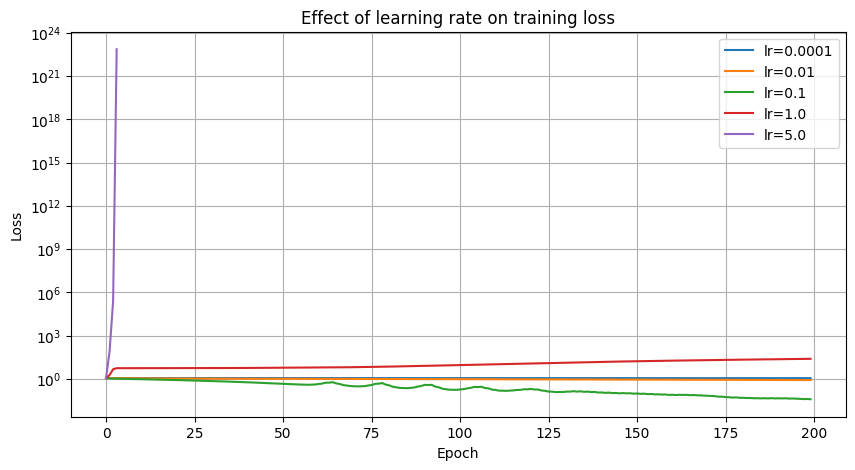

In [26]:
import torch, torch.nn as nn, matplotlib.pyplot as plt

def train_lr(lr, epochs=200, seed=0):
    torch.manual_seed(seed)
    net = nn.Sequential(
        nn.Linear(16, 64), nn.ReLU(),
        nn.Linear(64, 64), nn.ReLU(),
        nn.Linear(64, 1)
    )
    X = torch.randn(128, 16)
    y = torch.randn(128, 1)
    opt = torch.optim.SGD(net.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history = []
    for _ in range(epochs):
        opt.zero_grad()
        loss = criterion(net(X), y)
        if torch.isnan(loss): history.append(float("nan")); break
        loss.backward()
        opt.step()
        history.append(loss.item())
    return history

plt.figure(figsize=(10, 5))
for lr in [1e-4, 1e-2, 0.1, 1.0, 5.0]:
    h = train_lr(lr)
    plt.plot(h, label=f"lr={lr}")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")
plt.title("Effect of learning rate on training loss")
plt.legend()
plt.grid(True)
plt.show()

## Task 5.1: Diagnose Learning Rate Effects  (5 pts)


**Questions:**

- (a) Describe the loss curve shape for lr=1e-4, 1e-2, 0.1, 1.0, and 5.0.
- (b) Which learning rate gives the best convergence? How would you determine this systematically?
- (c) What does an oscillating or diverging loss curve indicate about the learning rate?

*Your answer:*

a) 
lr = 1e-4: Almost a straight line indicating slow loss decrease

lr = 1e-2: Almost a straight line as well but has a steadier loss decrease compared to 1e-4. 

lr = 0.1: Crooked line going down, which means loss is decreasing as epoch increases, indicating efficient learning

lr = 1.0: Plateau-like going up when epoch increases. 

lr = 5.0: It is almost a straight vertical line as it shoots up immediately after a few epochs, showing unstability. 


b) lr = 0.1 gave the best convergence. Determining the best one would be based of the final loss value, how fast the convergence is, and whether it oscillated or diverged.



c) Oscillating or diverging loss curve might indicate that the learning rate is too high. This means, gradient updates are too large, which causes overshooting or moving away from the minimum entirely.


## 5.2 Learning Rate Scheduling

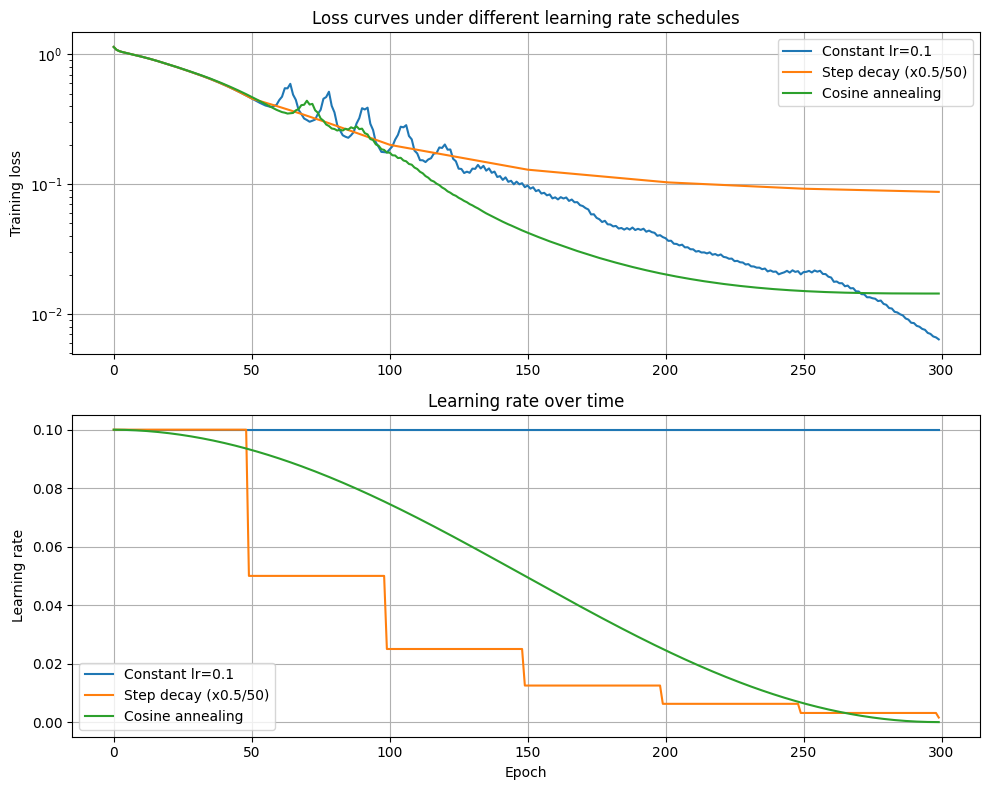

In [27]:
import torch, torch.nn as nn, matplotlib.pyplot as plt

def train_scheduled(schedule_fn, epochs=300, base_lr=0.1, seed=0):
    torch.manual_seed(seed)
    net = nn.Sequential(
        nn.Linear(16, 64), nn.ReLU(),
        nn.Linear(64, 64), nn.ReLU(),
        nn.Linear(64, 1)
    )
    X = torch.randn(128, 16)
    y = torch.randn(128, 1)
    opt = torch.optim.SGD(net.parameters(), lr=base_lr)
    scheduler = schedule_fn(opt)
    criterion = nn.MSELoss()
    history, lr_history = [], []
    for _ in range(epochs):
        opt.zero_grad()
        loss = criterion(net(X), y)
        loss.backward()
        opt.step()
        scheduler.step()
        history.append(loss.item())
        lr_history.append(opt.param_groups[0]["lr"])
    return history, lr_history

schedules = {
    "Constant lr=0.1":     lambda opt: torch.optim.lr_scheduler.ConstantLR(opt, factor=1.0),
    "Step decay (x0.5/50)":lambda opt: torch.optim.lr_scheduler.StepLR(opt, step_size=50, gamma=0.5),
    "Cosine annealing":    lambda opt: torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=300),
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
for label, fn in schedules.items():
    h, lr_h = train_scheduled(fn)
    ax1.plot(h,    label=label)
    ax2.plot(lr_h, label=label)

ax1.set_ylabel("Training loss"); ax1.set_yscale("log"); ax1.legend(); ax1.grid(True)
ax1.set_title("Loss curves under different learning rate schedules")
ax2.set_ylabel("Learning rate"); ax2.set_xlabel("Epoch"); ax2.legend(); ax2.grid(True)
ax2.set_title("Learning rate over time")
plt.tight_layout()
plt.show()

## Task 5.2: Learning Rate Scheduling  (5 pts)

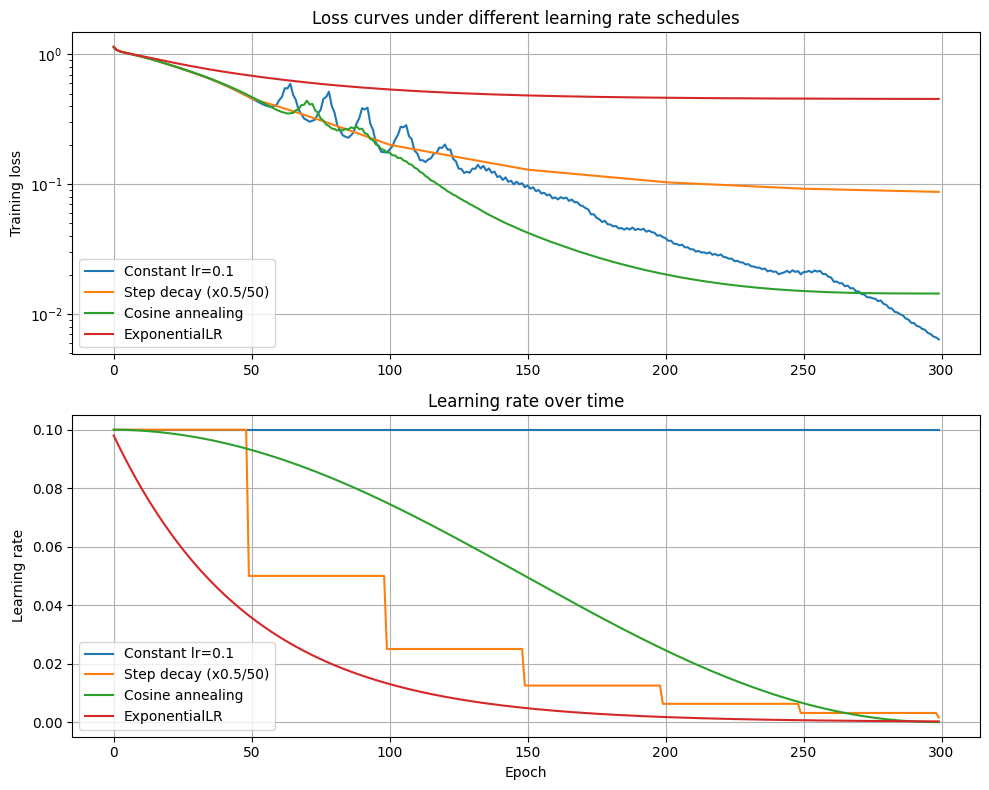

In [28]:
# Task 5.2 (c) -- add ExponentialLR to the comparison
import torch, torch.nn as nn, matplotlib.pyplot as plt

def train_scheduled(schedule_fn, epochs=300, base_lr=0.1, seed=0):
    torch.manual_seed(seed)
    net = nn.Sequential(
        nn.Linear(16, 64), nn.ReLU(),
        nn.Linear(64, 64), nn.ReLU(),
        nn.Linear(64, 1)
    )
    X = torch.randn(128, 16)
    y = torch.randn(128, 1)
    opt = torch.optim.SGD(net.parameters(), lr=base_lr)
    scheduler = schedule_fn(opt)
    criterion = nn.MSELoss()
    history, lr_history = [], []
    for _ in range(epochs):
        opt.zero_grad()
        loss = criterion(net(X), y)
        loss.backward()
        opt.step()
        scheduler.step()
        history.append(loss.item())
        lr_history.append(opt.param_groups[0]["lr"])
    return history, lr_history

schedules = {
    "Constant lr=0.1":     lambda opt: torch.optim.lr_scheduler.ConstantLR(opt, factor=1.0),
    "Step decay (x0.5/50)":lambda opt: torch.optim.lr_scheduler.StepLR(opt, step_size=50, gamma=0.5),
    "Cosine annealing":    lambda opt: torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=300),
    "ExponentialLR":       lambda opt: torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.98),
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
for label, fn in schedules.items():
    h, lr_h = train_scheduled(fn)
    ax1.plot(h,    label=label)
    ax2.plot(lr_h, label=label)

ax1.set_ylabel("Training loss"); ax1.set_yscale("log"); ax1.legend(); ax1.grid(True)
ax1.set_title("Loss curves under different learning rate schedules")
ax2.set_ylabel("Learning rate"); ax2.set_xlabel("Epoch"); ax2.legend(); ax2.grid(True)
ax2.set_title("Learning rate over time")
plt.tight_layout()
plt.show()

**Questions:**

- (a) Which schedule gives the best final loss? Explain why in terms of the bias-variance tradeoff of step size.
- (b) What is the intuition behind starting large and decaying: What is the practical benefit of starting with a high learning rate and decaying it?
- (c) Add `torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.98)` to the comparison. Where does it rank?

*Your answer:*


- (a) Obviously, the constant 1.0 learning rate gave the best final loss. Having a constant 1.0 learning rate means the network learns just as fast in any epoch and that might result to a higher variance as it may overfit the training data since it doesnt slow down in learning./
- (b) Having a large learning rate then decaying it over time will ensure that the network learned most of what it needs and then only slowing down to ensure that it does not overfit the data.
- (c) It ranks as the lowest in loss as the learning rate decayed rapidly. 